# Codigo Modelo LSTM

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, root_mean_squared_error,median_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Bidirectional 


# ==========================================
# 0. Lectura del Superdataset de precios horarios de la electricidad, generacion y climatología
# ==========================================
df_dummy = pd.read_csv('../../Dataset_unificado/Dataset_unificado1.csv', sep=";")
df_dummy['datetime'] = pd.to_datetime(df_dummy['datetime'])
df_dummy.set_index('datetime', inplace=True) 
# A partir de aquí, 'datetime' ya no es una columna

# ==========================================
# 1. PREPARACIÓN Y DIVISIÓN TEMPORAL
# ==========================================


indice_precio = df_dummy.columns.get_loc('price')

df_features = df_dummy.drop(columns=['price'])
df_target = df_dummy[['price']]

datos_precio = df_dummy['price'].values.reshape(-1, 1)
y = df_dummy['price']




scaler_X = MinMaxScaler(feature_range=(0, 1))
X_escalado = scaler_X.fit_transform(df_features)

scaler_y = MinMaxScaler(feature_range=(0, 1))
y_escalado = scaler_y.fit_transform(df_target)

#24
horas_pasadas = 168
X, y = [], []

for i in range(horas_pasadas, len(df_dummy)):
    X.append(X_escalado[i - horas_pasadas:i, :])        # Toma las columnas del pasado
    y.append(y_escalado[i, 0])             # Solo predice el precio del futuro

X, y = np.array(X), np.array(y)


limite_division = int(len(X) * 0.8)
X_train, X_test = X[:limite_division], X[limite_division:]
y_train, y_test = y[:limite_division], y[limite_division:]

model = Sequential([

    LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    
    Dense(units=1)
])

# Compilar el modelo utilizando el optimizador Adam y la pérdida por Error Cuadrático Medio
model.compile(optimizer='adam', loss='mean_squared_error')

#Entrenar el modelo
print("Iniciando el entrenamiento de la LSTM...")
model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))

#Realizar predicciones y revertir la normalización
predicciones_escaladas = model.predict(X_test)
# Volver los precios a su escala original
predicciones_reales = scaler_y.inverse_transform(predicciones_escaladas)
precios_reales_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))

print("\n¡Predicciones listas!")
print(f"Primera predicción del test: {predicciones_reales[0][0]:.2f} € (Valor real: {precios_reales_test[0][0]:.2f} €)")
mae = mean_absolute_error(precios_reales_test, predicciones_reales)
rmse = root_mean_squared_error(precios_reales_test, predicciones_reales)

print(f"Error Promedio (MAE): {mae:.2f} €")
print(f"Error Cuadrático (RMSE): {rmse:.2f} €")
# Convertir a vectores
y_true = precios_reales_test.flatten()
y_pred = predicciones_reales.flatten()

# MedAE
medae = median_absolute_error(y_true, y_pred)

# R²
r2 = r2_score(y_true, y_pred)

# wAPE
wape = (
    np.sum(np.abs(y_true - y_pred))
    / np.sum(np.abs(y_true))
) * 100

# sMAPE
denominador = (np.abs(y_true) + np.abs(y_pred)) / 2

with np.errstate(divide='ignore', invalid='ignore'):
    smape = np.abs(y_pred - y_true) / denominador
    smape = np.nan_to_num(smape)

smape = np.mean(smape) * 100

# Mostrar resultados
print("\n==============================================")
print("Resultados adicionales LSTM")
print("==============================================")
print(f"MedAE:   {medae:.4f} €/MWh")
print(f"R²:      {r2:.4f}")
print(f"wAPE:    {wape:.4f} %")
print(f"sMAPE:   {smape:.4f} %")
print("==============================================")


c:\Users\Jaime\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando el entrenamiento de la LSTM...
Epoch 1/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 90s 80ms/step - loss: 0.0038 - val_loss: 0.0035
Epoch 2/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 85s 78ms/step - loss: 0.0016 - val_loss: 0.0038
Epoch 3/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 84s 77ms/step - loss: 0.0012 - val_loss: 0.0035
Epoch 4/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 83s 76ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 5/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 92s 84ms/step - loss: 9.0623e-04 - val_loss: 0.0025
Epoch 6/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 90s 82ms/step - loss: 8.1184e-04 - val_loss: 0.0026
Epoch 7/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 91s 84ms/step - loss: 7.4607e-04 - val_loss: 0.0031
Epoch 8/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 85s 77ms/step - loss: 7.2163e-04 - val_loss: 0.0027
Epoch 9/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - loss: 6.4127e-04 - val_loss: 0.0034
Epoch 10/15
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 86s 79ms/step - loss: 6.5677e-04 - val_loss: 0.0036
Epoch 11/15
1092/1092 ━━━━━━━━━━━━

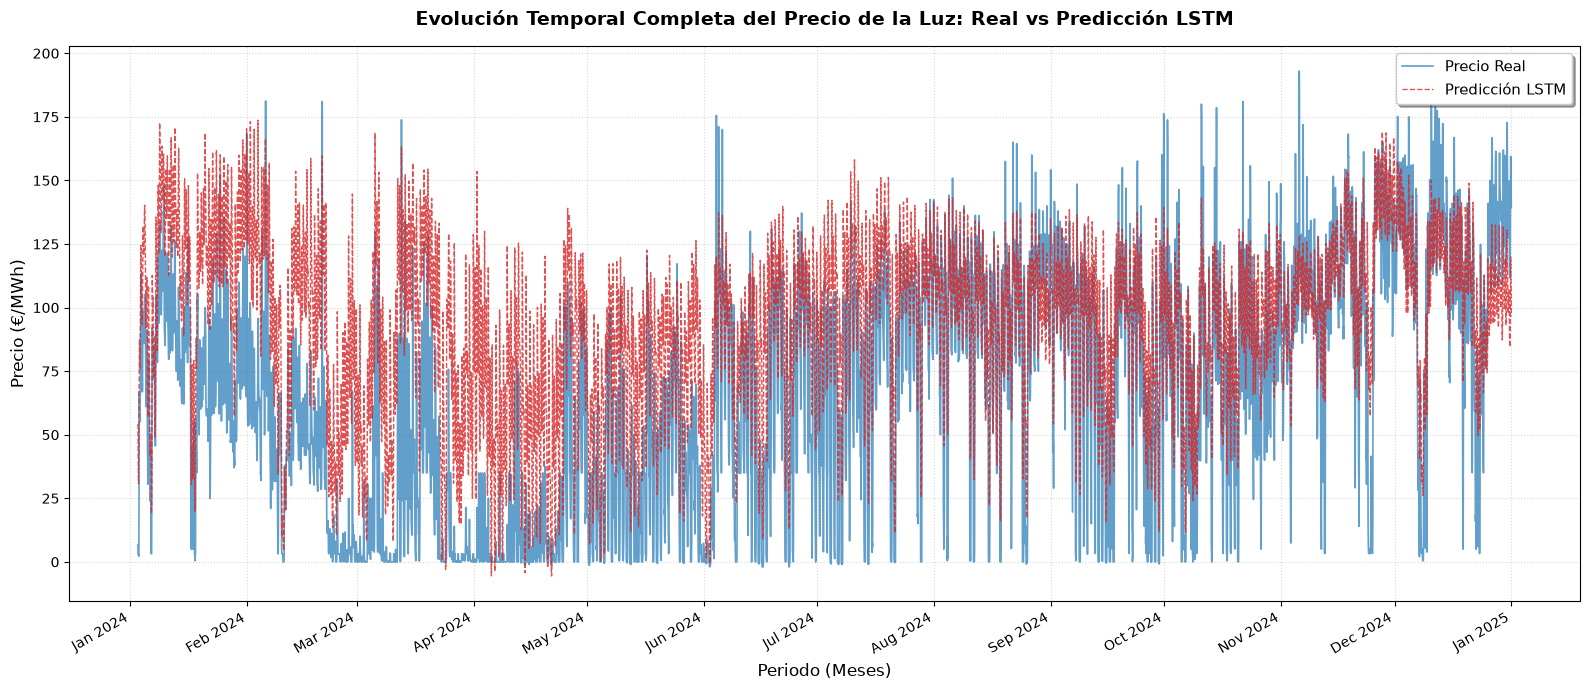

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# Generación de gráfica anual (Test completo)
# ==========================================
# 1. Extraer las fechas exactas alineadas con el conjunto de prueba (X_test)
fechas_completas = df_dummy.index[horas_pasadas:]
fechas_test = fechas_completas[limite_division:]

# 2. Estructurar los resultados en un DataFrame temporal
df_plot = pd.DataFrame({
    'Fecha': fechas_test,
    'Real': y_true,
    'Prediccion': y_pred
})
df_plot['Fecha'] = pd.to_datetime(df_plot['Fecha'])

# 3. Configurar dimensiones y trazado de curvas
fig, ax = plt.subplots(figsize=(16, 7))

# Trazado de líneas (con alpha y grosores optimizados para alto volumen de datos)
ax.plot(df_plot['Fecha'], df_plot['Real'], label='Precio Real', color='#1f77b4', alpha=0.7, linewidth=1.2)
ax.plot(df_plot['Fecha'], df_plot['Prediccion'], label='Predicción LSTM', color='#d62728', alpha=0.8, linestyle='--', linewidth=1.0)

# 4. Formatear eje X para marcas mensuales legibles
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()

# 5. Detalles estéticos y etiquetas
ax.set_title('Evolución Temporal Completa del Precio de la Luz: Real vs Predicción LSTM', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Periodo (Meses)', fontsize=12)
ax.set_ylabel('Precio (€/MWh)', fontsize=12)
ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.5)

# Desplegar gráfica por pantalla
plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# Generación de gráfica mensual específica
# ==========================================
# Selecciona aquí el año y mes concreto que deseas visualizar (ej. '2025-11')
mes_seleccionado = '2025-04'

# Filtrar el DataFrame por el periodo objetivo
df_mes = df_plot[df_plot['Fecha'].dt.to_period('M') == mes_seleccionado]

if df_mes.empty:
    print(f"\n[!] No existen registros para el periodo {mes_seleccionado} en el conjunto de test.")
    print(f"Rango disponible en test: {df_plot['Fecha'].min()} hasta {df_plot['Fecha'].max()}")
else:
    fig, ax = plt.subplots(figsize=(16, 7))

    # Graficar con marcadores discretos para identificar el comportamiento horario
    ax.plot(df_mes['Fecha'], df_mes['Real'], label='Precio Real', color='#1f77b4', marker='o', markersize=2, linewidth=1.5)
    ax.plot(df_mes['Fecha'], df_mes['Prediccion'], label='Predicción LSTM', color='#d62728', linestyle='--', linewidth=1.5)

    # Configurar marcas en el eje X cada 2 días para no saturar el texto
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    fig.autofmt_xdate()

    # Detalles de la visualización
    ax.set_title(f'Desglose Horario del Precio de la Luz ({mes_seleccionado}): Real vs Predicción LSTM', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Días del Mes', fontsize=12)
    ax.set_ylabel('Precio (€/MWh)', fontsize=12)
    ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()



[!] No existen registros para el periodo 2025-11 en el conjunto de test.
Rango disponible en test: 2024-01-03 00:00:00 hasta 2024-12-31 23:00:00


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.preprocessing import RobustScaler


# ==========================================
# 0. Lectura del Superdataset de precios horarios de la electricidad, generacion y climatología
# ==========================================
df_dummy_bi = pd.read_csv('../../Dataset_unificado/Dataset_unificado1.csv', sep=";")
df_dummy_bi['datetime'] = pd.to_datetime(df_dummy_bi['datetime'])
df_dummy_bi.set_index('datetime', inplace=True) 
# A partir de aquí, 'datetime' ya no es una columna

# ==========================================
# 1. PREPARACIÓN Y DIVISIÓN TEMPORAL
# ==========================================



reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,          # Reduce el learning rate a la mitad
    patience=3,          # Si en 3 épocas no mejora
    min_lr=1e-5          # Límite mínimo
)

callbacks_lista = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    reduce_lr
]

indice_precio = df_dummy_bi.columns.get_loc('price')

df_features = df_dummy_bi.drop(columns=['price'])
df_target = df_dummy_bi[['price']]

datos_precio = df_dummy_bi['price'].values.reshape(-1, 1)
y = df_dummy_bi['price']




scaler_X = MinMaxScaler(feature_range=(0, 1))
X_escalado = scaler_X.fit_transform(df_features)

scaler_y = RobustScaler()
y_escalado = scaler_y.fit_transform(df_target)

#24
horas_pasadas = 168
paso = 1 # <- tocar para avanzar mas horas (de 1 en 1, de 2 en 2, etc.)
X, y = [], []

for i in range(horas_pasadas, len(df_dummy_bi), paso):
    X.append(X_escalado[i - horas_pasadas:i, :])        
    y.append(y_escalado[i, 0])             

X, y = np.array(X), np.array(y)

limite_division = int(len(X) * 0.8)
X_train, X_test = X[:limite_division], X[limite_division:]
y_train, y_test = y[:limite_division], y[limite_division:]

model = Sequential([
    # Eliminamos Bidirectional y recurrent_dropout. Activamos la aceleración cuDNN nativa.
    LSTM(
        units=128, 
        activation='tanh', 
        kernel_regularizer=tf.keras.regularizers.l2(0.001), 
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),
    Dropout(0.2),
    
    LSTM(
        units=64, 
        activation='tanh',
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        return_sequences=False
    ),
    Dropout(0.2),
    
    Dense(units=32, activation='swish'), 
    Dense(units=1)
])

# Compilar el modelo utilizando el optimizador Adam y la pérdida por Error Cuadrático Medio
# REEMPLAZA TU MODEL.COMPILE POR ESTO:
model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4), loss=tf.keras.losses.Huber())

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True  # Se queda con los mejores pesos guardados
)

#Entrenar el modelo
print("Iniciando el entrenamiento de la LSTM...")
model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=256, # <- NUEVO: Lotes más grandes para procesar en paralelo a máxima velocidad
    validation_data=(X_test, y_test), 
    callbacks=[early_stop]
)

#Realizar predicciones y revertir la normalización
predicciones_escaladas = model.predict(X_test)
# Volver los precios a su escala original
predicciones_reales = scaler_y.inverse_transform(predicciones_escaladas)
precios_reales_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))

print("\n¡Predicciones listas!")
print(f"Primera predicción del test: {predicciones_reales[0][0]:.2f} € (Valor real: {precios_reales_test[0][0]:.2f} €)")
mae = mean_absolute_error(precios_reales_test, predicciones_reales)
rmse = root_mean_squared_error(precios_reales_test, predicciones_reales)

print(f"Error Promedio (MAE): {mae:.2f} €")
print(f"Error Cuadrático (RMSE): {rmse:.2f} €")


c:\Users\Jaime\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando el entrenamiento de la LSTM...
Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 66s 910ms/step - loss: 0.2636 - val_loss: 0.3011
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 59s 859ms/step - loss: 0.1286 - val_loss: 0.2394
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 55s 800ms/step - loss: 0.0939 - val_loss: 0.2044
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 58s 838ms/step - loss: 0.0778 - val_loss: 0.1686
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 871ms/step - loss: 0.0675 - val_loss: 0.1803
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 58s 841ms/step - loss: 0.0593 - val_loss: 0.1569
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 58s 842ms/step - loss: 0.0523 - val_loss: 0.1188
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 60s 863ms/step - loss: 0.0463 - val_loss: 0.1138
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 58s 841ms/step - loss: 0.0443 - val_loss: 0.1546
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 59s 856ms/step - loss: 0.0399 - val_loss: 0.0985
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 59s 854ms/step - loss: 0.0384 - val_loss: 0.0826


# Codigo Modelo GRU

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, median_absolute_error, r2_score 
from sklearn.preprocessing import MinMaxScaler, RobustScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# Cargar los datos
datos = pd.read_csv(
    '../../Dataset_unificado/Dataset_unificado1.csv',
    sep=';'
)

datos['fecha_hora'] = pd.to_datetime(datos['datetime'])

datos = datos.sort_values('fecha_hora')
datos = datos.set_index('fecha_hora')

# La columna original ya no es necesaria
datos = datos.drop(columns=['datetime'])


# Variables relacionadas con la fecha
# Se transforman las variables periódicas para que el modelo
# pueda representar mejor la relación entre horas, días y meses.
datos['hora_sin'] = np.sin(2 * np.pi * datos['hour'] / 24)
datos['hora_cos'] = np.cos(2 * np.pi * datos['hour'] / 24)

datos['dia_sin'] = np.sin(2 * np.pi * datos['dayofweek'] / 7)
datos['dia_cos'] = np.cos(2 * np.pi * datos['dayofweek'] / 7)

datos['mes_sin'] = np.sin(2 * np.pi * datos['month'] / 12)
datos['mes_cos'] = np.cos(2 * np.pi * datos['month'] / 12)


# Precio de la hora anterior
datos['precio_hora_anterior'] = datos['price'].shift(1)

# El primer registro no tiene un valor anterior, por lo que se elimina.
datos = datos.dropna()


# Ya no se necesitan estas columnas porque se han creado
# las variables cíclicas correspondientes.
datos = datos.drop(
    columns=['year', 'month', 'day', 'dayofweek', 'hour']
)


# Variables de entrada y variable que queremos predecir
variables_entrada = datos.drop(
    columns=['price', 'precio_hora_anterior']
)

variable_objetivo = datos[['price']]

precio_hora_anterior = datos[['precio_hora_anterior']]


# Normalización
# Para las variables de entrada se utiliza MinMaxScaler.
# Para el precio se utiliza RobustScaler para reducir
# el efecto que puedan tener valores extremos.
escalador_entrada = MinMaxScaler()
escalador_precio = RobustScaler()

variables_entrada_escaladas = escalador_entrada.fit_transform(
    variables_entrada
)

precio_escalado = escalador_precio.fit_transform(
    variable_objetivo
)

precio_anterior_escalado = escalador_precio.transform(
    precio_hora_anterior.values
)


# Se juntan las variables normales con el precio de la hora anterior.
datos_escalados = np.hstack(
    (variables_entrada_escaladas, precio_anterior_escalado)
)


# Crear las secuencias que se utilizarán como entrada de la GRU
# 168 horas corresponden a una semana completa.
tamano_ventana = 168
paso = 2

entradas = []
salidas = []

for i in range(
    tamano_ventana,
    len(datos_escalados),
    paso
):
    entradas.append(
        datos_escalados[
            i - tamano_ventana:i,
            :
        ]
    )

    salidas.append(
        precio_escalado[i, 0]
    )


entradas = np.array(entradas)
salidas = np.array(salidas)


# Separación temporal de los datos
# Al tratarse de una serie temporal no se mezclan los datos.
numero_datos = len(entradas)

fin_entrenamiento = int(
    numero_datos * 0.70
)

fin_validacion = int(
    numero_datos * 0.85
)


entradas_entrenamiento = entradas[
    :fin_entrenamiento
]

salidas_entrenamiento = salidas[
    :fin_entrenamiento
]


entradas_validacion = entradas[
    fin_entrenamiento:fin_validacion
]

salidas_validacion = salidas[
    fin_entrenamiento:fin_validacion
]


entradas_prueba = entradas[
    fin_validacion:
]

salidas_prueba = salidas[
    fin_validacion:
]


print(
    "Datos de entrenamiento:",
    entradas_entrenamiento.shape
)

print(
    "Datos de validación:",
    entradas_validacion.shape
)

print(
    "Datos de prueba:",
    entradas_prueba.shape
)


# Modelo GRU
modelo = Sequential()


modelo.add(
    GRU(
        64,
        activation='tanh',
        return_sequences=True,
        kernel_regularizer=tf.keras.regularizers.l2(0.0001),
        input_shape=(
            entradas_entrenamiento.shape[1],
            entradas_entrenamiento.shape[2]
        )
    )
)


modelo.add(
    Dropout(0.2)
)


modelo.add(
    GRU(
        32,
        activation='tanh',
        return_sequences=False,
        kernel_regularizer=tf.keras.regularizers.l2(0.0001)
    )
)


modelo.add(
    Dropout(0.2)
)


modelo.add(
    Dense(
        16,
        activation='swish'
    )
)

modelo.add(
    Dense(1)
)


# Configuración del entrenamiento
modelo.compile(
    optimizer=AdamW(
        learning_rate=0.0005,
        weight_decay=0.0001
    ),
    loss=tf.keras.losses.Huber()
)


# Se utiliza el conjunto de validación para controlar
# el entrenamiento.
parada_temprana = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


reduccion_tasa_aprendizaje = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)


# Entrenamiento
print("Comenzando entrenamiento...")


historial = modelo.fit(
    entradas_entrenamiento,
    salidas_entrenamiento,
    epochs=40,
    batch_size=64,
    validation_data=(
        entradas_validacion,
        salidas_validacion
    ),
    callbacks=[
        parada_temprana,
        reduccion_tasa_aprendizaje
    ]
)


# Predicción sobre el conjunto de prueba
predicciones_escaladas = modelo.predict(
    entradas_prueba
)


# Volver a las unidades originales del precio
predicciones = escalador_precio.inverse_transform(
    predicciones_escaladas
)

precios_reales = escalador_precio.inverse_transform(
    salidas_prueba.reshape(-1, 1)
)


# Evaluación
error_mae = mean_absolute_error(
    precios_reales,
    predicciones
)

error_rmse = root_mean_squared_error(
    precios_reales,
    predicciones
)

y_true_flat = precios_reales.flatten()
y_pred_flat = predicciones.flatten()

error_medae = median_absolute_error(y_true_flat, y_pred_flat)
r2_score_val = r2_score(y_true_flat, y_pred_flat)


error_wape = (np.sum(np.abs(y_true_flat - y_pred_flat)) / np.sum(np.abs(y_true_flat))) * 100


smape_denominator = (np.abs(y_true_flat) + np.abs(y_pred_flat)) / 2
with np.errstate(divide='ignore', invalid='ignore'):
    smape_elements = np.abs(y_pred_flat - y_true_flat) / smape_denominator
    smape_elements = np.nan_to_num(smape_elements)
error_smape = np.mean(smape_elements) * 100


print("\nResultados del modelo")
print(f"MAE:  {error_mae:.4f}")
print(f"RMSE: {error_rmse:.4f}")
print("\n" + "="*52)
print(f"{'MedAE (€/MWh)':<16} {'R2':<8} {'wAPE (%)':<12} {'sMAPE (%)':<12}")
print("-" * 52)
print(f"{error_medae:<16.4f} {r2_score_val:<8.4f} {error_wape:<12.4f} {error_smape:<12.4f}")
print("="*52 + "\n")


c:\Users\Jaime\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


Datos de entrenamiento: (15287, 168, 34)
Datos de validación: (3277, 168, 34)
Datos de prueba: (3276, 168, 34)


c:\Users\Jaime\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Comenzando entrenamiento...
Epoch 1/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 36s 135ms/step - loss: 0.0691 - val_loss: 0.0254 - learning_rate: 5.0000e-04
Epoch 2/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 32s 133ms/step - loss: 0.0362 - val_loss: 0.0195 - learning_rate: 5.0000e-04
Epoch 3/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 32s 132ms/step - loss: 0.0301 - val_loss: 0.0175 - learning_rate: 5.0000e-04
Epoch 4/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 32s 132ms/step - loss: 0.0262 - val_loss: 0.0165 - learning_rate: 5.0000e-04
Epoch 5/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 32s 132ms/step - loss: 0.0239 - val_loss: 0.0149 - learning_rate: 5.0000e-04
Epoch 6/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 32s 133ms/step - loss: 0.0225 - val_loss: 0.0144 - learning_rate: 5.0000e-04
Epoch 7/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 32s 133ms/step - loss: 0.0210 - val_loss: 0.0153 - learning_rate: 5.0000e-04
Epoch 8/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 32s 134ms/step - loss: 0.0200 - val_loss: 0.0133 - learning_rate: 5.0000e-04
Epoch 9/40
239/239 ━━━━━━━━━━━━━━━━━

# Representacion Grafica

Número de fechas: 3276
Número de predicciones: 3276

Periodo seleccionado:
2024-01-01 hasta 2024-12-31
Número de datos: 3276

Primeros datos:
                fecha  precio_real  precio_predicho
0 2024-04-03 01:00:00         1.68         9.121887
1 2024-04-03 03:00:00         1.00         5.283310
2 2024-04-03 05:00:00         1.00         7.736977
3 2024-04-03 07:00:00        28.07        15.173637
4 2024-04-03 09:00:00         5.50        23.050606


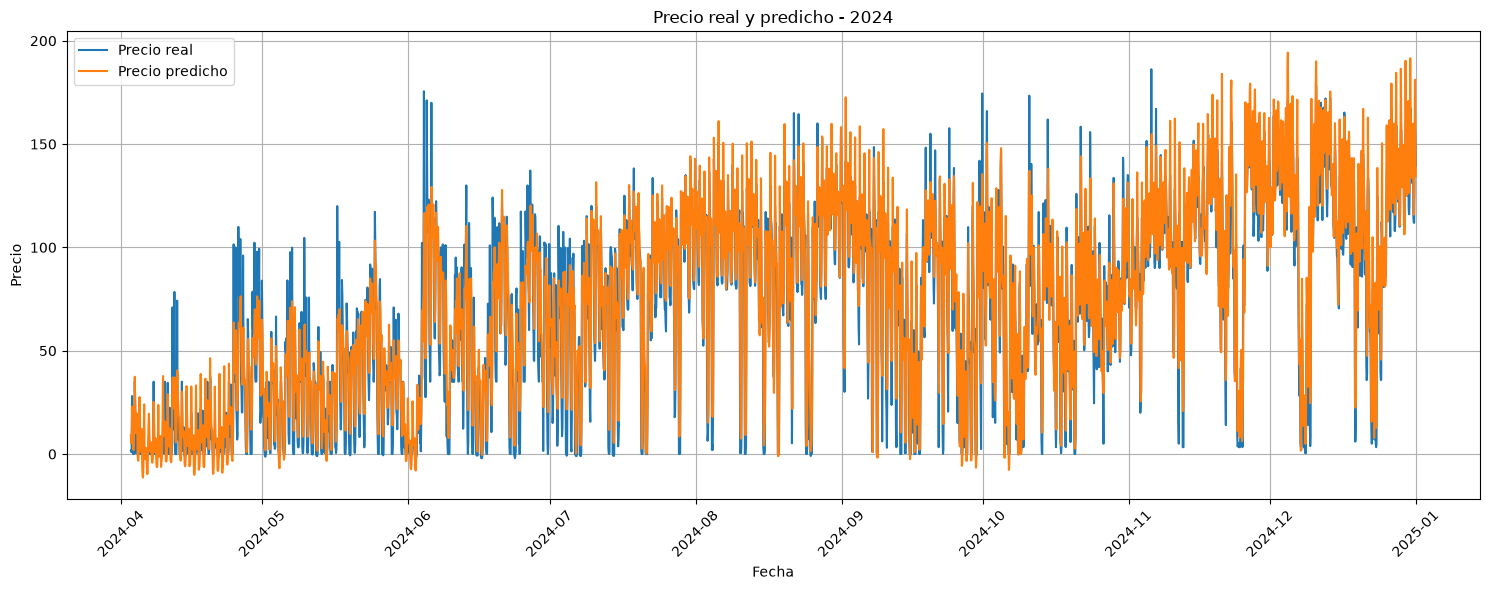

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# AÑO QUE QUEREMOS REPRESENTAR
# ============================================================

ano = 2024  # Quitamos la variable 'mes' ya que usaremos el año completo


# ============================================================
# Fechas asociadas a las predicciones
# ============================================================

fechas = datos.index[tamano_ventana::paso]

# Nos quedamos con las fechas correspondientes al conjunto de prueba
fechas_prueba = fechas[fin_validacion:]


# Comprobar que el número de fechas coincide con las predicciones
print("Número de fechas:", len(fechas_prueba))
print("Número de predicciones:", len(predicciones))


# ============================================================
# Crear DataFrame con los resultados
# ============================================================

resultados = pd.DataFrame({
    'fecha': fechas_prueba,
    'precio_real': precios_reales.flatten(),
    'precio_predicho': predicciones.flatten()
})


# ============================================================
# Seleccionar el AÑO indicado (Modificado)
# ============================================================

inicio_ano = pd.Timestamp(year=ano, month=1, day=1)
inicio_ano_siguiente = pd.Timestamp(year=ano + 1, month=1, day=1)

# Filtramos los datos para que cubran desde el 1 de enero hasta antes del 1 de enero del año siguiente
datos_ano = resultados[
    (resultados['fecha'] >= inicio_ano) &
    (resultados['fecha'] < inicio_ano_siguiente)
]


# ============================================================
# Mostrar información
# ============================================================

print("\nPeriodo seleccionado:")
print(inicio_ano.strftime("%Y-%m-%d"), "hasta",
      (inicio_ano_siguiente - pd.Timedelta(days=1)).strftime("%Y-%m-%d"))

print("Número de datos:", len(datos_ano))

if len(datos_ano) > 0:

    print("\nPrimeros datos:")
    print(datos_ano.head())


    # ========================================================
    # Gráfico
    # ========================================================

    plt.figure(figsize=(15, 6))

    plt.plot(
        datos_ano['fecha'],
        datos_ano['precio_real'],
        label='Precio real'
    )

    plt.plot(
        datos_ano['fecha'],
        datos_ano['precio_predicho'],
        label='Precio predicho'
    )

    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    # Cambiado para mostrar solo el año en el título
    plt.title(f'Precio real y predicho - {ano}') 

    plt.legend()
    plt.grid(True)

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:

    print(
        f"\nNo hay datos disponibles para el año "
        f"{ano} dentro del conjunto de prueba."
    )


Número de fechas: 3276
Número de predicciones: 3276
La primera fecha disponible es: 2024-04-03 01:00:00
La última fecha disponible es: 2024-12-31 23:00:00

Periodo seleccionado: 2024-06
Número de datos: 360

Primeros datos:
                  fecha  precio_real  precio_predicho
708 2024-06-01 01:00:00         3.25         7.002228
709 2024-06-01 03:00:00         1.23         5.273804
710 2024-06-01 05:00:00         3.25         5.349854
711 2024-06-01 07:00:00         3.25         6.546791
712 2024-06-01 09:00:00         0.00        -1.746971


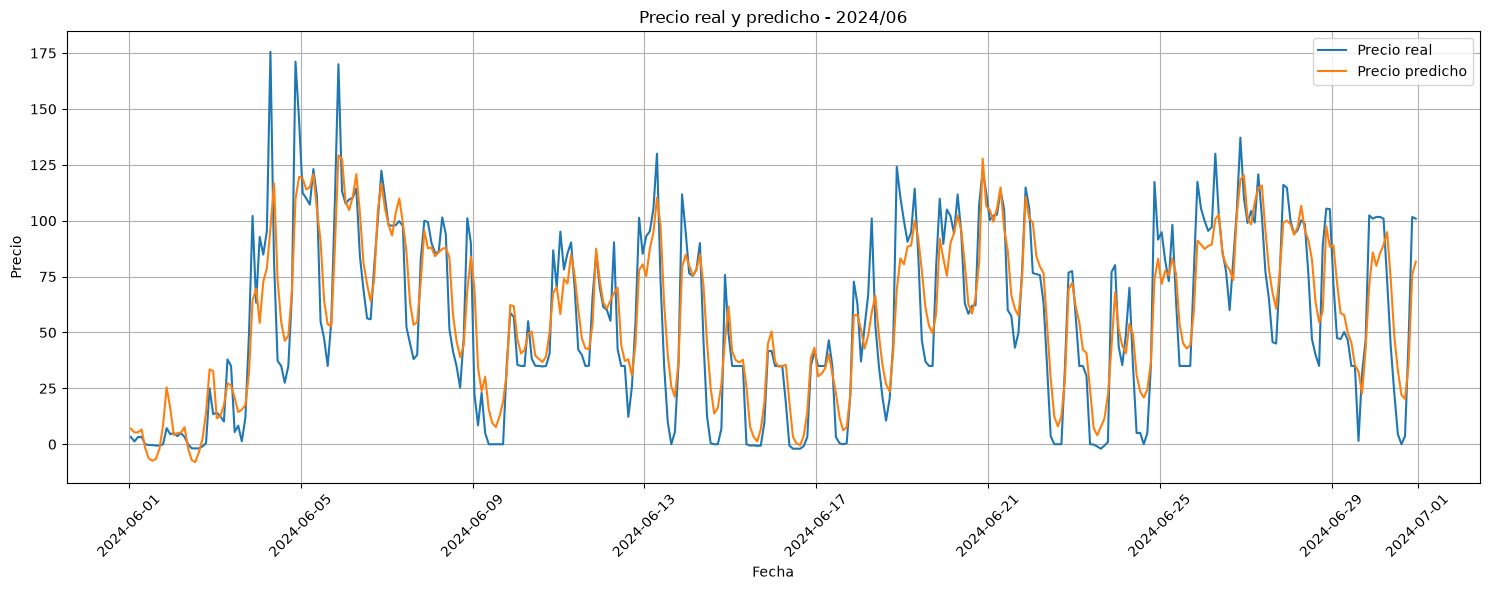

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# MES Y AÑO QUE QUEREMOS REPRESENTAR
# ============================================================

ano = 2024
mes = 6  # Cambia este número (1 al 12) para ver el mes que quieras


# ============================================================
# Fechas asociadas a las predicciones
# ============================================================

fechas = datos.index[tamano_ventana::paso]

# Nos quedamos con las fechas correspondientes al conjunto de prueba
fechas_prueba = fechas[fin_validacion:]


# Comprobar que el número de fechas coincide con las predicciones
print("Número de fechas:", len(fechas_prueba))
print("Número de predicciones:", len(predicciones))


# ============================================================
# Crear DataFrame con los resultados
# ============================================================

resultados = pd.DataFrame({
    'fecha': fechas_prueba,
    'precio_real': precios_reales.flatten(),
    'precio_predicho': predicciones.flatten()
})

print("La primera fecha disponible es:", resultados['fecha'].min())
print("La última fecha disponible es:", resultados['fecha'].max())

# ============================================================
# Seleccionar el mes indicado (Modificado de forma simple)
# ============================================================

# Filtramos directamente por las propiedades de año y mes de la columna fecha
datos_mes = resultados[
    (resultados['fecha'].dt.year == ano) & 
    (resultados['fecha'].dt.month == mes)
]


# ============================================================
# Mostrar información
# ============================================================

print(f"\nPeriodo seleccionado: {ano}-{mes:02d}")
print("Número de datos:", len(datos_mes))

if len(datos_mes) > 0:

    print("\nPrimeros datos:")
    print(datos_mes.head())


    # ========================================================
    # Gráfico
    # ========================================================

    plt.figure(figsize=(15, 6))

    plt.plot(
        datos_mes['fecha'],
        datos_mes['precio_real'],
        label='Precio real'
    )

    plt.plot(
        datos_mes['fecha'],
        datos_mes['precio_predicho'],
        label='Precio predicho'
    )

    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    plt.title(f'Precio real y predicho - {ano}/{mes:02d}')

    plt.legend()
    plt.grid(True)

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:

    print(
        f"\nNo hay datos disponibles para "
        f"{ano}/{mes:02d} dentro del conjunto de prueba."
    )
